Iniciando processamento paralelo...
Tempo total: 14.73 s
Total True B+ (K+): 38599 | Total True B- (K-): 39028


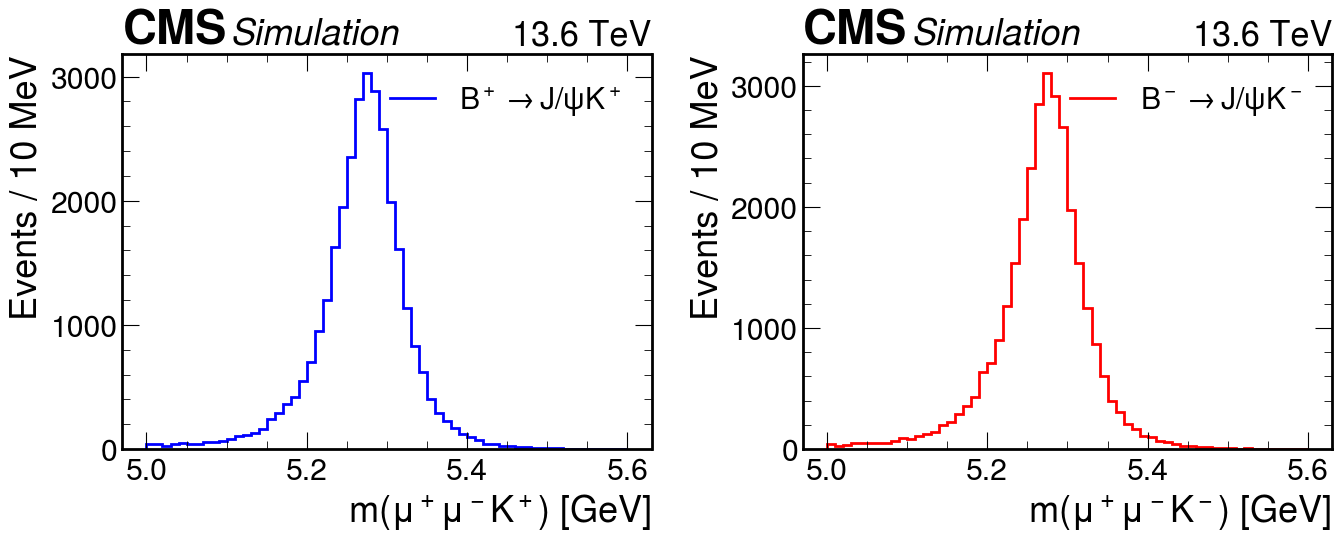

In [1]:
import uproot
import awkward as ak
import vector
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import glob
import time
from multiprocessing import Pool

vector.register_awkward()
hep.style.use("CMS")

data_dir = "/cms/store/user/tdeandra/BuToJpsiK_JpsiToMuMu_MuFilter_Pt-2_TuneCP5_13p6TeV_pythia8-evtgen/BPH_NanoAOD_Run2022C_MC/260127_232047/0000"
tree_name = "Events"
workers = 16

# Todas as variáveis de cinemática e as variáveis de ÍNDICE necessárias para cruzar as coleções
branches_to_load = [
    "BToTrkTrkMuMu_fit_l1_pt", "BToTrkTrkMuMu_fit_l1_eta", "BToTrkTrkMuMu_fit_l1_phi",
    "BToTrkTrkMuMu_fit_l2_pt", "BToTrkTrkMuMu_fit_l2_eta", "BToTrkTrkMuMu_fit_l2_phi",
    "BToTrkTrkMuMu_fit_trk1_pt", "BToTrkTrkMuMu_fit_trk1_eta", "BToTrkTrkMuMu_fit_trk1_phi",
    "BToTrkTrkMuMu_fit_trk2_pt", "BToTrkTrkMuMu_fit_trk2_eta", "BToTrkTrkMuMu_fit_trk2_phi",
    "BToTrkTrkMuMu_charge_trk1", "BToTrkTrkMuMu_charge_trk2",
    # Índices de ligação
    "BToTrkTrkMuMu_l1_idx", "BToTrkTrkMuMu_l2_idx",
    "BToTrkTrkMuMu_trk1_idx", "BToTrkTrkMuMu_trk2_idx",
    "Muon_genPartIdx", "Track_genPartFlav", "GenPart_pdgId"
]

M_MU = 0.105658
M_K  = 0.493677

def process_single_file(f):
    try:
        data = uproot.concatenate([f"{f}:{tree_name}"], branches_to_load, library="ak")
    except Exception:
        return None

    if len(data) == 0: return None

    # --- 1. Quadrivetores ---
    p4_l1 = ak.zip({"pt": data["BToTrkTrkMuMu_fit_l1_pt"], "eta": data["BToTrkTrkMuMu_fit_l1_eta"], "phi": data["BToTrkTrkMuMu_fit_l1_phi"], "mass": M_MU}, with_name="Momentum4D")
    p4_l2 = ak.zip({"pt": data["BToTrkTrkMuMu_fit_l2_pt"], "eta": data["BToTrkTrkMuMu_fit_l2_eta"], "phi": data["BToTrkTrkMuMu_fit_l2_phi"], "mass": M_MU}, with_name="Momentum4D")
    p4_trk1 = ak.zip({"pt": data["BToTrkTrkMuMu_fit_trk1_pt"], "eta": data["BToTrkTrkMuMu_fit_trk1_eta"], "phi": data["BToTrkTrkMuMu_fit_trk1_phi"], "mass": M_K}, with_name="Momentum4D")
    p4_trk2 = ak.zip({"pt": data["BToTrkTrkMuMu_fit_trk2_pt"], "eta": data["BToTrkTrkMuMu_fit_trk2_eta"], "phi": data["BToTrkTrkMuMu_fit_trk2_phi"], "mass": M_K}, with_name="Momentum4D")

    # --- 2. TRUTH MATCHING VIA ÍNDICES CRUZADOS ---
    
    # Função auxiliar para cruzar BToTrkTrkMuMu -> Muon -> GenPart
    def is_true_muon_by_idx(mu_idx_cand):
        muon_gen_idx_array = data["Muon_genPartIdx"]
        gen_pdg_array = data["GenPart_pdgId"]
        
        # Pulo 1: Do Candidato para o Múon
        valid_mu = (mu_idx_cand >= 0) & (mu_idx_cand < ak.num(muon_gen_idx_array))
        safe_mu_idx = ak.where(valid_mu, mu_idx_cand, 0)
        gen_idx = muon_gen_idx_array[safe_mu_idx]
        
        # Pulo 2: Do Múon para o GenPart
        valid_gen = valid_mu & (gen_idx >= 0) & (gen_idx < ak.num(gen_pdg_array))
        safe_gen_idx = ak.where(valid_gen, gen_idx, 0)
        
        # Confirma se é múon verdadeiro
        return valid_gen & (abs(gen_pdg_array[safe_gen_idx]) == 13)

    # Função auxiliar para cruzar BToTrkTrkMuMu -> Track -> Track_genPartFlav
    def is_true_track_by_idx(trk_idx_cand):
        track_flav_array = data["Track_genPartFlav"]
        
        # Acessa a coleção de traços
        valid_trk = (trk_idx_cand >= 0) & (trk_idx_cand < ak.num(track_flav_array))
        safe_trk_idx = ak.where(valid_trk, trk_idx_cand, 0)
        
        # Se Flavour != 0, a simulação confirma que é um traço real do decaimento
        return valid_trk & (track_flav_array[safe_trk_idx] != 0)

    # Aplica as verificações via índice
    is_true_muons = is_true_muon_by_idx(data["BToTrkTrkMuMu_l1_idx"]) & is_true_muon_by_idx(data["BToTrkTrkMuMu_l2_idx"])
    is_true_K1 = is_true_track_by_idx(data["BToTrkTrkMuMu_trk1_idx"])
    is_true_K2 = is_true_track_by_idx(data["BToTrkTrkMuMu_trk2_idx"])

    # --- 3. Filtragem de Massa e Associação ---
    p4_jpsi = p4_l1 + p4_l2
    mask_jpsi = (p4_jpsi.mass > 2.95) & (p4_jpsi.mass < 3.25)

    valid_mask_trk1 = mask_jpsi & is_true_muons & is_true_K1
    valid_mask_trk2 = mask_jpsi & is_true_muons & is_true_K2

    mass_b_trk1 = (p4_jpsi + p4_trk1).mass[valid_mask_trk1]
    chg_b_trk1 = data["BToTrkTrkMuMu_charge_trk1"][valid_mask_trk1]

    mass_b_trk2 = (p4_jpsi + p4_trk2).mass[valid_mask_trk2]
    chg_b_trk2 = data["BToTrkTrkMuMu_charge_trk2"][valid_mask_trk2]

    # Achata os arrays filtrados
    all_valid_masses = ak.concatenate([ak.flatten(mass_b_trk1), ak.flatten(mass_b_trk2)])
    all_valid_charges = ak.concatenate([ak.flatten(chg_b_trk1), ak.flatten(chg_b_trk2)])

    if len(all_valid_masses) == 0: return None

    # Separa os candidatos validados pelo cruzamento de índices baseando-se na carga reconstruída
    return {
        "b_plus": all_valid_masses[all_valid_charges > 0],
        "b_minus": all_valid_masses[all_valid_charges < 0],
    }

print("Iniciando processamento paralelo...")
t0 = time.time()

files = glob.glob(f"{data_dir}/*.root")
if not files: raise RuntimeError("Nenhum arquivo encontrado.")

# Executa o Pool disparando a função para cada arquivo
with Pool(processes=workers) as pool:
    results = pool.map(process_single_file, files)

# Remove os Nones (arquivos vazios ou com erro)
results = [r for r in results if r is not None]

if not results: raise RuntimeError("Nenhum evento sobreviveu aos cortes e ao truth matching.")

# Extrai e converte tudo direto para NumPy Arrays
final_b_plus   = ak.to_numpy(ak.concatenate([r["b_plus"] for r in results]))
final_b_minus  = ak.to_numpy(ak.concatenate([r["b_minus"] for r in results]))

print(f"Tempo total: {time.time() - t0:.2f} s")
print(f"Total True B+ (K+): {len(final_b_plus)} | Total True B- (K-): {len(final_b_minus)}")

# --- 4. Plotting (Estilo Nota de Análise) ---
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
bins, m_range = 60, (5.0, 5.6)

# K+ (B+)
hep.histplot(
    np.histogram(final_b_plus, bins=bins, range=m_range)[0],
    bins=np.linspace(*m_range, bins+1),
    histtype="step", color="blue", label=r"$B^+ \to J/\psi K^+$", lw=2, ax=ax[0]
)
ax[0].set_xlabel(r"$m(\mu^+\mu^-K^+)$ [GeV]")
ax[0].set_ylabel("Events / 10 MeV")
ax[0].legend(loc="upper right")
hep.cms.label(data=False, rlabel="13.6 TeV", ax=ax[0])

# K- (B-)
hep.histplot(
    np.histogram(final_b_minus, bins=bins, range=m_range)[0],
    bins=np.linspace(*m_range, bins+1),
    histtype="step", color="red", label=r"$B^- \to J/\psi K^-$", lw=2, ax=ax[1]
)
ax[1].set_xlabel(r"$m(\mu^+\mu^-K^-)$ [GeV]")
ax[1].set_ylabel("Events / 10 MeV")
ax[1].legend(loc="upper right")
hep.cms.label(data=False, rlabel="13.6 TeV", ax=ax[1])

plt.tight_layout()
plt.savefig("AnalysisNote_BPlus_BMinus_IndexMatched.png")
plt.show()

/home/tandrade/.local/lib/python3.9/site-packages/zfit/__init__.py:63: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


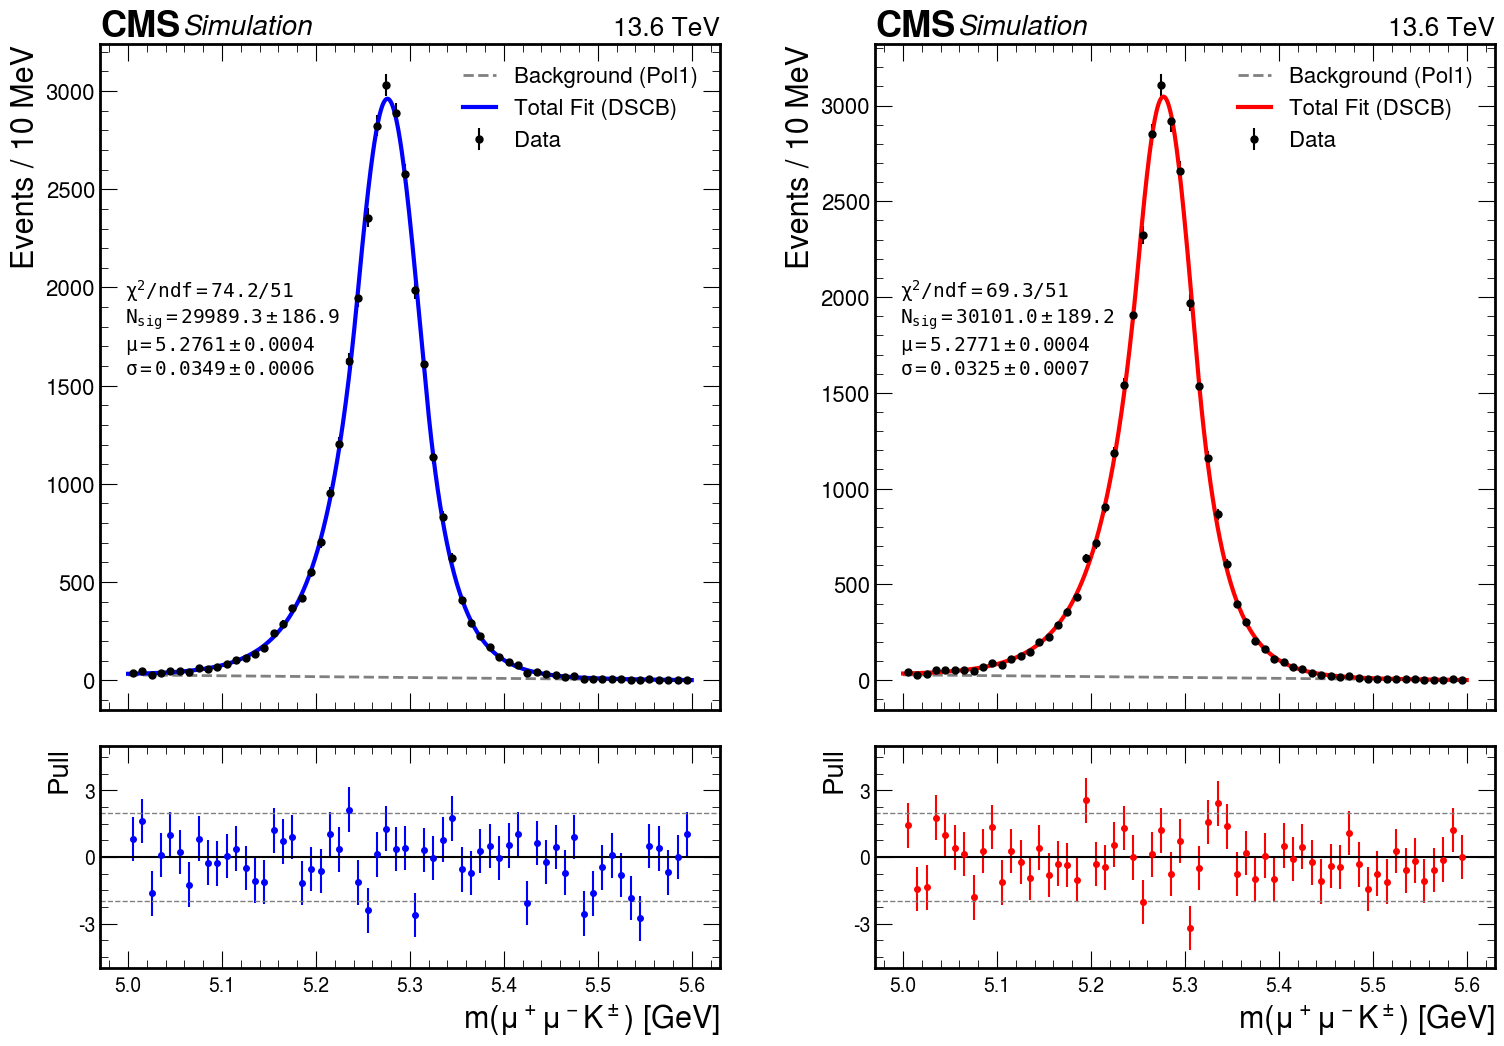

In [2]:
import zfit
from matplotlib import gridspec
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

def perform_fit_and_plot(data_array, ax_main, ax_pull, title, color):
    # 1. Definir o Espaço e Parâmetros
    obs = zfit.Space("m", limits=(5.0, 5.6))
    
    # --- Parâmetros do SINAL (Double Crystal Ball) ---
    mu = zfit.Parameter(f"mu_{title}", 5.28, 5.25, 5.32)
    sigma = zfit.Parameter(f"sigma_{title}", 0.03, 0.005, 0.06)
    
    alL = zfit.Parameter(f"alL_{title}", 1.5, 0.1, 5.0)
    nL = zfit.Parameter(f"nL_{title}", 2.0, 0.1, 30.0)
    alR = zfit.Parameter(f"alR_{title}", 1.5, 0.1, 5.0)
    nR = zfit.Parameter(f"nR_{title}", 2.0, 0.1, 30.0)
    
    yield_sig = zfit.Parameter(f"yield_sig_{title}", len(data_array)*0.7, 0, len(data_array)*1.2)
    
    pdf_sig = zfit.pdf.DoubleCB(mu=mu, sigma=sigma, alphal=alL, nl=nL, alphar=alR, nr=nR, obs=obs)
    model_sig_ext = pdf_sig.create_extended(yield_sig)

    # --- Parâmetros do FUNDO (Chebyshev Pol1) ---
    a0 = zfit.Parameter(f"a0_{title}", -0.1, -1.0, 1.0)
    yield_bkg = zfit.Parameter(f"yield_bkg_{title}", len(data_array)*0.3, 0, len(data_array)*1.2)
    pdf_bkg = zfit.pdf.Chebyshev(obs=obs, coeffs=[a0])
    model_bkg_ext = pdf_bkg.create_extended(yield_bkg)

    model = zfit.pdf.SumPDF([model_sig_ext, model_bkg_ext])
    data_zfit = zfit.Data.from_numpy(obs=obs, array=data_array)
    
    # 2. Minimização
    nll = zfit.loss.ExtendedUnbinnedNLL(model, data_zfit)
    minimizer = zfit.minimize.Minuit()
    result = minimizer.minimize(nll)
    result.hesse() 
    
    # 3. Plotagem
    bin_width = (5.6 - 5.0) / 60
    counts, bin_edges = np.histogram(data_array, bins=60, range=(5.0, 5.6))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    y_err_data = np.sqrt(counts)
    
    ax_main.errorbar(bin_centers, counts, yerr=y_err_data, fmt='ko', capsize=0, elinewidth=1.5, ms=5, label="Data")
    
    x_plot = np.linspace(5.0, 5.6, 1000)
    y_bkg = model_bkg_ext.pdf(x_plot).numpy() * yield_bkg.numpy() * bin_width
    y_total = model.pdf(x_plot).numpy() * (yield_sig.numpy() + yield_bkg.numpy()) * bin_width
    
    ax_main.plot(x_plot, y_bkg, color='gray', linestyle='--', lw=2, label="Background (Pol1)")
    ax_main.plot(x_plot, y_total, color=color, lw=3, label="Total Fit (DSCB)")
    
    # 4. Chi2 e Pulls
    model_counts = model.pdf(bin_centers).numpy() * (yield_sig.numpy() + yield_bkg.numpy()) * bin_width
    pull_output = np.zeros(counts.shape, dtype=np.float64)
    pulls = np.divide(counts - model_counts, y_err_data, out=pull_output, where=y_err_data!=0)
    
    chi2 = np.sum(pulls**2)
    ndf = len(counts) - 9 
    
    # 5. Estética CMS e Info Box (Fontes maiores)
    ax_main.set_ylabel(f"Events / {bin_width*1000:.0f} MeV", fontsize=22)
    # Aumentando a legenda
    ax_main.legend(fontsize=16, loc='upper right', frameon=False)
    
    # Label CMS (Tamanho padrão do mplhep é ajustável)
    hep.cms.label(data=False, rlabel="13.6 TeV", ax=ax_main, fontsize=20)
    
    # Info Box com fonte maior e mais clara
    info_text = (
        f"$\chi^2/ndf = {chi2:.1f}/{ndf}$\n"
        f"$N_{{sig}} = {yield_sig.numpy():.1f} \pm {result.params[yield_sig]['hesse']['error']:.1f}$\n"
        f"$\mu = {mu.numpy():.4f} \pm {result.params[mu]['hesse']['error']:.4f}$\n"
        f"$\sigma = {sigma.numpy():.4f} \pm {result.params[sigma]['hesse']['error']:.4f}$"
    )
    # fontsize=14 para o texto do fit
    ax_main.text(0.04, 0.65, info_text, transform=ax_main.transAxes, 
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'), 
                 fontsize=14, family='monospace', verticalalignment='top')

    # 6. Plot do Pull
    ax_pull.errorbar(bin_centers, pulls, yerr=1, fmt='o', color=color, markersize=4, elinewidth=1.5)
    ax_pull.axhline(0, color='black', linestyle='-', lw=1.5)
    for s in [-2, 2]: ax_pull.axhline(s, color='gray', linestyle='--', lw=1)
    
    ax_pull.set_ylim(-5, 5)
    ax_pull.set_yticks([-3, 0, 3])
    ax_pull.tick_params(axis='both', which='major', labelsize=14)
    ax_pull.set_ylabel("Pull", fontsize=20)
    ax_pull.set_xlabel(r"$m(\mu^+\mu^-K^\pm)$ [GeV]", fontsize=22)

# --- GridSpec ---
fig = plt.figure(figsize=(18, 12)) # Aumentei um pouco o tamanho da figura total
gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0.08, wspace=0.25)

ax0_main = plt.subplot(gs[0, 0]); ax0_pull = plt.subplot(gs[1, 0], sharex=ax0_main)
perform_fit_and_plot(final_b_plus, ax0_main, ax0_pull, "Bplus", "blue")

ax1_main = plt.subplot(gs[0, 1]); ax1_pull = plt.subplot(gs[1, 1], sharex=ax1_main)
perform_fit_and_plot(final_b_minus, ax1_main, ax1_pull, "Bminus", "red")

# Ajuste fino de ticks
ax0_main.tick_params(axis='both', which='major', labelsize=16)
ax1_main.tick_params(axis='both', which='major', labelsize=16)

plt.setp(ax0_main.get_xticklabels(), visible=False)
plt.setp(ax1_main.get_xticklabels(), visible=False)
plt.show()

Iniciando processamento paralelo...
Tempo total: 16.77 s
Total True B+ (K+): 9795 | Total True B- (K-): 1980


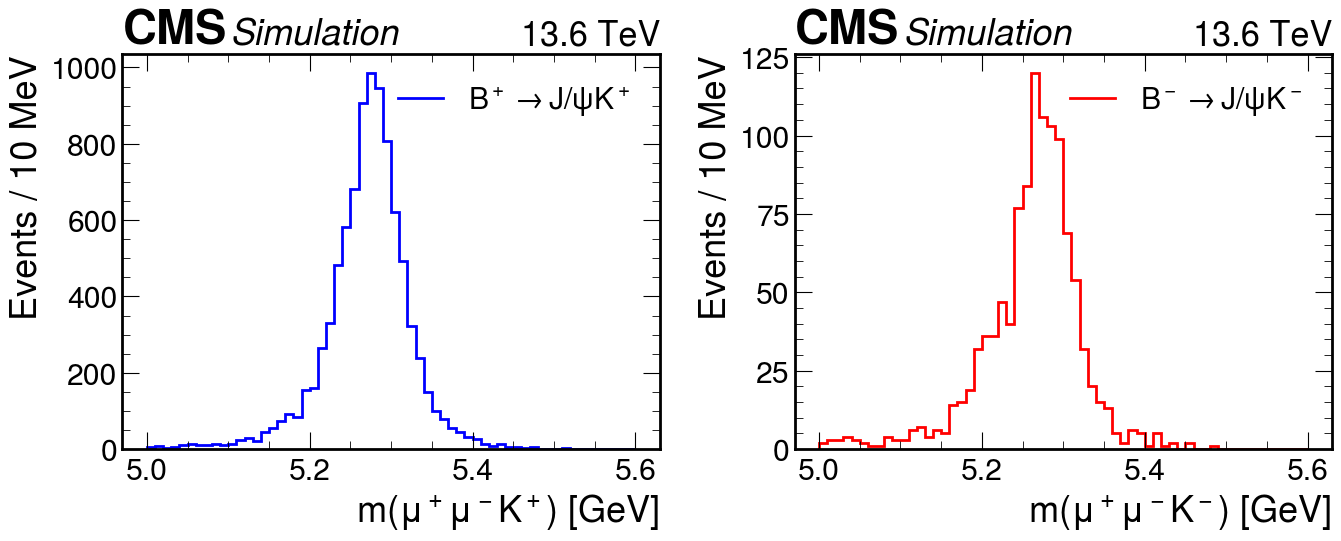

In [3]:
import uproot
import awkward as ak
import vector
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import glob
import time
from multiprocessing import Pool

vector.register_awkward()
hep.style.use("CMS")

# --- CONFIGURAÇÃO ---
data_dir = "/cms/store/user/tdeandra/BuToJpsiK_JpsiToMuMu_MuFilter_Pt-2_TuneCP5_13p6TeV_pythia8-evtgen/BPH_NanoAOD_Run2022C_MC/260127_232047/0000"
tree_name = "Events"
workers = 16

M_MU = 0.105658
M_K  = 0.493677

# --- VARIÁVEIS PARA CARREGAR ---
branches_to_load = [
    "BToTrkTrkMuMu_fit_l1_pt", "BToTrkTrkMuMu_fit_l1_eta", "BToTrkTrkMuMu_fit_l1_phi",
    "BToTrkTrkMuMu_fit_l2_pt", "BToTrkTrkMuMu_fit_l2_eta", "BToTrkTrkMuMu_fit_l2_phi",
    "BToTrkTrkMuMu_fit_trk1_pt", "BToTrkTrkMuMu_fit_trk1_eta", "BToTrkTrkMuMu_fit_trk1_phi",
    "BToTrkTrkMuMu_fit_trk2_pt", "BToTrkTrkMuMu_fit_trk2_eta", "BToTrkTrkMuMu_fit_trk2_phi",
    "BToTrkTrkMuMu_charge_trk1", "BToTrkTrkMuMu_charge_trk2",
    
    "BToTrkTrkMuMu_l1_idx", "BToTrkTrkMuMu_l2_idx",
    "BToTrkTrkMuMu_trk1_idx", "BToTrkTrkMuMu_trk2_idx",
    "BToTrkTrkMuMu_ll_idx", 
    
    "Muon_genPartIdx", "Track_genPartFlav", "GenPart_pdgId",
    
    "Muon_softMvaRun3",
    "MuMu_pt", "MuMu_svprob", "MuMu_l_xy", "MuMu_l_xy_unc", "MuMu_fit_cos2D",
    
    "BToTrkTrkMuMu_fit_ditrack_mass_Kpi", "BToTrkTrkMuMu_fit_ditrack_mass_piK",
    "BToTrkTrkMuMu_fit_ditrack_mass_KK"
]

def process_single_file(f):
    try:
        data = uproot.concatenate([f"{f}:{tree_name}"], branches_to_load, library="ak")
    except Exception as e:
        print(f"\n[ERRO DE LEITURA] Falha ao processar {f.split('/')[-1]}: {e}\n")
        return None

    if len(data) == 0: return None

    # --- 1. Quadrivetores ---
    p4_l1 = ak.zip({"pt": data["BToTrkTrkMuMu_fit_l1_pt"], "eta": data["BToTrkTrkMuMu_fit_l1_eta"], "phi": data["BToTrkTrkMuMu_fit_l1_phi"], "mass": M_MU}, with_name="Momentum4D")
    p4_l2 = ak.zip({"pt": data["BToTrkTrkMuMu_fit_l2_pt"], "eta": data["BToTrkTrkMuMu_fit_l2_eta"], "phi": data["BToTrkTrkMuMu_fit_l2_phi"], "mass": M_MU}, with_name="Momentum4D")
    p4_trk1 = ak.zip({"pt": data["BToTrkTrkMuMu_fit_trk1_pt"], "eta": data["BToTrkTrkMuMu_fit_trk1_eta"], "phi": data["BToTrkTrkMuMu_fit_trk1_phi"], "mass": M_K}, with_name="Momentum4D")
    p4_trk2 = ak.zip({"pt": data["BToTrkTrkMuMu_fit_trk2_pt"], "eta": data["BToTrkTrkMuMu_fit_trk2_eta"], "phi": data["BToTrkTrkMuMu_fit_trk2_phi"], "mass": M_K}, with_name="Momentum4D")

    # --- 2. TRUTH MATCHING BLINDADO ---
    def is_true_muon_by_idx(mu_idx_cand):
        muon_gen_idx_array = data["Muon_genPartIdx"]
        gen_pdg_array = data["GenPart_pdgId"]
        
        # Máscara segura: se o índice for inválido, vira None
        valid_mu = (mu_idx_cand >= 0) & (mu_idx_cand < ak.num(muon_gen_idx_array))
        safe_mu_idx = ak.mask(mu_idx_cand, valid_mu)
        gen_idx = ak.fill_none(muon_gen_idx_array[safe_mu_idx], -1)
        
        valid_gen = (gen_idx >= 0) & (gen_idx < ak.num(gen_pdg_array))
        safe_gen_idx = ak.mask(gen_idx, valid_gen)
        gen_pdg = ak.fill_none(gen_pdg_array[safe_gen_idx], 0)
        
        return abs(gen_pdg) == 13

    def is_true_track_by_idx(trk_idx_cand):
        track_flav_array = data["Track_genPartFlav"]
        valid_trk = (trk_idx_cand >= 0) & (trk_idx_cand < ak.num(track_flav_array))
        safe_trk_idx = ak.mask(trk_idx_cand, valid_trk)
        track_flav = ak.fill_none(track_flav_array[safe_trk_idx], 0)
        return track_flav != 0

    is_true_muons = is_true_muon_by_idx(data["BToTrkTrkMuMu_l1_idx"]) & is_true_muon_by_idx(data["BToTrkTrkMuMu_l2_idx"])
    is_true_K1 = is_true_track_by_idx(data["BToTrkTrkMuMu_trk1_idx"])
    is_true_K2 = is_true_track_by_idx(data["BToTrkTrkMuMu_trk2_idx"])

    # --- 3. CORTES DE ANÁLISE BLINDADOS ---
    
    # A) SoftMVA dos Múons
    num_muons = ak.num(data["Muon_softMvaRun3"])
    valid_l1 = (data["BToTrkTrkMuMu_l1_idx"] >= 0) & (data["BToTrkTrkMuMu_l1_idx"] < num_muons)
    valid_l2 = (data["BToTrkTrkMuMu_l2_idx"] >= 0) & (data["BToTrkTrkMuMu_l2_idx"] < num_muons)
    
    safe_l1 = ak.mask(data["BToTrkTrkMuMu_l1_idx"], valid_l1)
    safe_l2 = ak.mask(data["BToTrkTrkMuMu_l2_idx"], valid_l2)
    
    mva_l1 = ak.fill_none(data["Muon_softMvaRun3"][safe_l1], -99.0)
    mva_l2 = ak.fill_none(data["Muon_softMvaRun3"][safe_l2], -99.0)
    cut_muon_mva = (mva_l1 > 0.74) & (mva_l2 > 0.74)

    # B) Propriedades do Dimúon (MuMu)
    num_mumu = ak.num(data["MuMu_pt"])
    valid_mumu = (data["BToTrkTrkMuMu_ll_idx"] >= 0) & (data["BToTrkTrkMuMu_ll_idx"] < num_mumu)
    safe_mumu = ak.mask(data["BToTrkTrkMuMu_ll_idx"], valid_mumu)

    val_mumu_pt = ak.fill_none(data["MuMu_pt"][safe_mumu], -99.0)
    val_mumu_svprob = ak.fill_none(data["MuMu_svprob"][safe_mumu], -99.0)
    val_mumu_lxy = ak.fill_none(data["MuMu_l_xy"][safe_mumu], -99.0)
    val_mumu_lxy_unc = ak.fill_none(data["MuMu_l_xy_unc"][safe_mumu], 1.0) # Proteção div por zero
    val_mumu_cos2d = ak.fill_none(data["MuMu_fit_cos2D"][safe_mumu], -99.0)

    cut_mumu = (
        (val_mumu_pt > 6.9) & 
        (val_mumu_svprob > 0.1) & 
        ((val_mumu_lxy / val_mumu_lxy_unc) > 3) & 
        (val_mumu_cos2d > 0.9)
    )

    # C) Cortes de Cinemática e Massa do Candidato B
    cut_ditrack_mass_diff = abs(data["BToTrkTrkMuMu_fit_ditrack_mass_Kpi"] - 0.896) < abs(data["BToTrkTrkMuMu_fit_ditrack_mass_piK"] - 0.896)
    
    cut_kin = (
        (data["BToTrkTrkMuMu_fit_l1_pt"] > 4) & (abs(data["BToTrkTrkMuMu_fit_l1_eta"]) < 2.4) &
        (data["BToTrkTrkMuMu_fit_l2_pt"] > 4) & (abs(data["BToTrkTrkMuMu_fit_l2_eta"]) < 2.4) &
        (data["BToTrkTrkMuMu_fit_trk1_pt"] > 0.8) & (abs(data["BToTrkTrkMuMu_fit_trk1_eta"]) < 2.4)
    )

    cut_ditrack_kk = data["BToTrkTrkMuMu_fit_ditrack_mass_KK"] > 1.035

    # D) Combinação de todos os cortes
    analysis_cuts_mask = cut_muon_mva & cut_mumu & cut_ditrack_mass_diff & cut_kin & cut_ditrack_kk

    # --- 4. FILTRAGEM FINAL ---
    p4_jpsi = p4_l1 + p4_l2
    mask_jpsi = (p4_jpsi.mass > 2.95) & (p4_jpsi.mass < 3.25)

    valid_mask_trk1 = mask_jpsi & is_true_muons & is_true_K1 & analysis_cuts_mask
    valid_mask_trk2 = mask_jpsi & is_true_muons & is_true_K2 & analysis_cuts_mask

    mass_b_trk1 = (p4_jpsi + p4_trk1).mass[valid_mask_trk1]
    chg_b_trk1 = data["BToTrkTrkMuMu_charge_trk1"][valid_mask_trk1]

    mass_b_trk2 = (p4_jpsi + p4_trk2).mass[valid_mask_trk2]
    chg_b_trk2 = data["BToTrkTrkMuMu_charge_trk2"][valid_mask_trk2]

    all_valid_masses = ak.concatenate([ak.flatten(mass_b_trk1), ak.flatten(mass_b_trk2)])
    all_valid_charges = ak.concatenate([ak.flatten(chg_b_trk1), ak.flatten(chg_b_trk2)])

    if len(all_valid_masses) == 0: return None

    return {
        "b_plus": all_valid_masses[all_valid_charges > 0],
        "b_minus": all_valid_masses[all_valid_charges < 0],
    }

# --- EXECUÇÃO ---
if __name__ == "__main__":
    print("Iniciando processamento paralelo...")
    t0 = time.time()

    files = glob.glob(f"{data_dir}/*.root")
    if not files: raise RuntimeError("Nenhum arquivo encontrado.")

    with Pool(processes=workers) as pool:
        results = pool.map(process_single_file, files)

    results = [r for r in results if r is not None]

    if not results:
        print("\n[AVISO] Todos os arquivos retornaram None. Nenhum evento sobreviveu aos cortes.")
        raise RuntimeError("Nenhum evento sobreviveu.")

    final_b_plus   = ak.to_numpy(ak.concatenate([r["b_plus"] for r in results]))
    final_b_minus  = ak.to_numpy(ak.concatenate([r["b_minus"] for r in results]))

    print(f"Tempo total: {time.time() - t0:.2f} s")
    print(f"Total True B+ (K+): {len(final_b_plus)} | Total True B- (K-): {len(final_b_minus)}")

    # --- PLOTTING ---
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    bins, m_range = 60, (5.0, 5.6)

    # K+ (B+)
    hep.histplot(
        np.histogram(final_b_plus, bins=bins, range=m_range)[0],
        bins=np.linspace(*m_range, bins+1),
        histtype="step", color="blue", label=r"$B^+ \to J/\psi K^+$", lw=2, ax=ax[0]
    )
    ax[0].set_xlabel(r"$m(\mu^+\mu^-K^+)$ [GeV]")
    ax[0].set_ylabel("Events / 10 MeV")
    ax[0].legend(loc="upper right")
    hep.cms.label(data=False, rlabel="13.6 TeV", ax=ax[0])

    # K- (B-)
    hep.histplot(
        np.histogram(final_b_minus, bins=bins, range=m_range)[0],
        bins=np.linspace(*m_range, bins+1),
        histtype="step", color="red", label=r"$B^- \to J/\psi K^-$", lw=2, ax=ax[1]
    )
    ax[1].set_xlabel(r"$m(\mu^+\mu^-K^-)$ [GeV]")
    ax[1].set_ylabel("Events / 10 MeV")
    ax[1].legend(loc="upper right")
    hep.cms.label(data=False, rlabel="13.6 TeV", ax=ax[1])

    plt.tight_layout()
    plt.savefig("AnalysisNote_BPlus_BMinus_IndexMatched.png")
    plt.show()

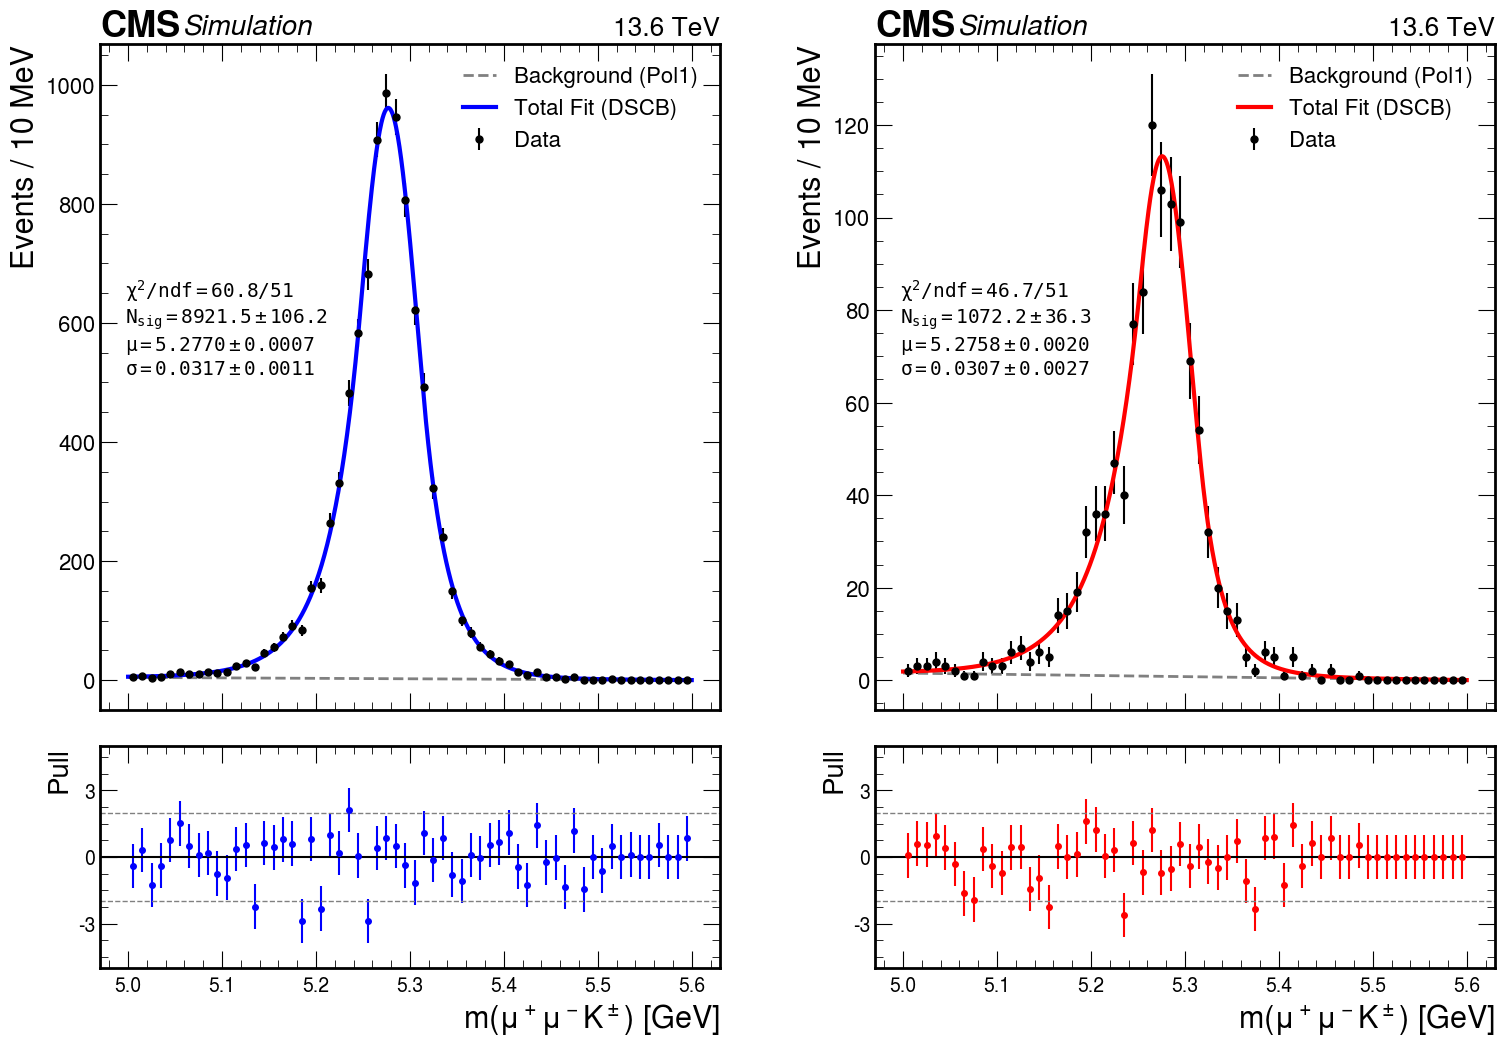

In [4]:
import zfit
from matplotlib import gridspec
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

def perform_fit_and_plot(data_array, ax_main, ax_pull, title, color):
    # 1. Definir o Espaço e Parâmetros
    obs = zfit.Space("m", limits=(5.0, 5.6))
    
    # --- Parâmetros do SINAL (Double Crystal Ball) ---
    mu = zfit.Parameter(f"mu_{title}", 5.28, 5.25, 5.32)
    sigma = zfit.Parameter(f"sigma_{title}", 0.03, 0.005, 0.06)
    
    alL = zfit.Parameter(f"alL_{title}", 1.5, 0.1, 5.0)
    nL = zfit.Parameter(f"nL_{title}", 2.0, 0.1, 30.0)
    alR = zfit.Parameter(f"alR_{title}", 1.5, 0.1, 5.0)
    nR = zfit.Parameter(f"nR_{title}", 2.0, 0.1, 30.0)
    
    yield_sig = zfit.Parameter(f"yield_sig_{title}", len(data_array)*0.7, 0, len(data_array)*1.2)
    
    pdf_sig = zfit.pdf.DoubleCB(mu=mu, sigma=sigma, alphal=alL, nl=nL, alphar=alR, nr=nR, obs=obs)
    model_sig_ext = pdf_sig.create_extended(yield_sig)

    # --- Parâmetros do FUNDO (Chebyshev Pol1) ---
    a0 = zfit.Parameter(f"a0_{title}", -0.1, -1.0, 1.0)
    yield_bkg = zfit.Parameter(f"yield_bkg_{title}", len(data_array)*0.3, 0, len(data_array)*1.2)
    pdf_bkg = zfit.pdf.Chebyshev(obs=obs, coeffs=[a0])
    model_bkg_ext = pdf_bkg.create_extended(yield_bkg)

    model = zfit.pdf.SumPDF([model_sig_ext, model_bkg_ext])
    data_zfit = zfit.Data.from_numpy(obs=obs, array=data_array)
    
    # 2. Minimização
    nll = zfit.loss.ExtendedUnbinnedNLL(model, data_zfit)
    minimizer = zfit.minimize.Minuit()
    result = minimizer.minimize(nll)
    result.hesse() 
    
    # 3. Plotagem
    bin_width = (5.6 - 5.0) / 60
    counts, bin_edges = np.histogram(data_array, bins=60, range=(5.0, 5.6))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    y_err_data = np.sqrt(counts)
    
    ax_main.errorbar(bin_centers, counts, yerr=y_err_data, fmt='ko', capsize=0, elinewidth=1.5, ms=5, label="Data")
    
    x_plot = np.linspace(5.0, 5.6, 1000)
    y_bkg = model_bkg_ext.pdf(x_plot).numpy() * yield_bkg.numpy() * bin_width
    y_total = model.pdf(x_plot).numpy() * (yield_sig.numpy() + yield_bkg.numpy()) * bin_width
    
    ax_main.plot(x_plot, y_bkg, color='gray', linestyle='--', lw=2, label="Background (Pol1)")
    ax_main.plot(x_plot, y_total, color=color, lw=3, label="Total Fit (DSCB)")
    
    # 4. Chi2 e Pulls
    model_counts = model.pdf(bin_centers).numpy() * (yield_sig.numpy() + yield_bkg.numpy()) * bin_width
    pull_output = np.zeros(counts.shape, dtype=np.float64)
    pulls = np.divide(counts - model_counts, y_err_data, out=pull_output, where=y_err_data!=0)
    
    chi2 = np.sum(pulls**2)
    ndf = len(counts) - 9 
    
    # 5. Estética CMS e Info Box (Fontes maiores)
    ax_main.set_ylabel(f"Events / {bin_width*1000:.0f} MeV", fontsize=22)
    # Aumentando a legenda
    ax_main.legend(fontsize=16, loc='upper right', frameon=False)
    
    # Label CMS (Tamanho padrão do mplhep é ajustável)
    hep.cms.label(data=False, rlabel="13.6 TeV", ax=ax_main, fontsize=20)
    
    # Info Box com fonte maior e mais clara
    info_text = (
        f"$\chi^2/ndf = {chi2:.1f}/{ndf}$\n"
        f"$N_{{sig}} = {yield_sig.numpy():.1f} \pm {result.params[yield_sig]['hesse']['error']:.1f}$\n"
        f"$\mu = {mu.numpy():.4f} \pm {result.params[mu]['hesse']['error']:.4f}$\n"
        f"$\sigma = {sigma.numpy():.4f} \pm {result.params[sigma]['hesse']['error']:.4f}$"
    )
    # fontsize=14 para o texto do fit
    ax_main.text(0.04, 0.65, info_text, transform=ax_main.transAxes, 
                 bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'), 
                 fontsize=14, family='monospace', verticalalignment='top')

    # 6. Plot do Pull
    ax_pull.errorbar(bin_centers, pulls, yerr=1, fmt='o', color=color, markersize=4, elinewidth=1.5)
    ax_pull.axhline(0, color='black', linestyle='-', lw=1.5)
    for s in [-2, 2]: ax_pull.axhline(s, color='gray', linestyle='--', lw=1)
    
    ax_pull.set_ylim(-5, 5)
    ax_pull.set_yticks([-3, 0, 3])
    ax_pull.tick_params(axis='both', which='major', labelsize=14)
    ax_pull.set_ylabel("Pull", fontsize=20)
    ax_pull.set_xlabel(r"$m(\mu^+\mu^-K^\pm)$ [GeV]", fontsize=22)

# --- GridSpec ---
fig = plt.figure(figsize=(18, 12)) # Aumentei um pouco o tamanho da figura total
gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0.08, wspace=0.25)

ax0_main = plt.subplot(gs[0, 0]); ax0_pull = plt.subplot(gs[1, 0], sharex=ax0_main)
perform_fit_and_plot(final_b_plus, ax0_main, ax0_pull, "Bplus", "blue")

ax1_main = plt.subplot(gs[0, 1]); ax1_pull = plt.subplot(gs[1, 1], sharex=ax1_main)
perform_fit_and_plot(final_b_minus, ax1_main, ax1_pull, "Bminus", "red")

# Ajuste fino de ticks
ax0_main.tick_params(axis='both', which='major', labelsize=16)
ax1_main.tick_params(axis='both', which='major', labelsize=16)

plt.setp(ax0_main.get_xticklabels(), visible=False)
plt.setp(ax1_main.get_xticklabels(), visible=False)
plt.show()